# 03 — Matrix Factorization

This notebook covers two matrix factorization approaches:
- **SGD** — trained iteratively, learns user and item bias terms
- **SVD** — closed-form analytical solution using scipy

Both address the sparsity problem from notebook 02 by learning dense latent
representations where even users with no shared ratings can be meaningfully compared.

**Sections**
1. Setup
2. Matrix Factorization with SGD
3. Matrix Factorization with SVD
4. Latent space visualization
5. Qualitative recommendation inspection
6. Evaluation and comparison

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA

from data_loader import load_all
from encoder import encode
from splitter import split
from matrix_builder import build_sparse_matrix
from mf_scratch import MatrixFactorizationSGD
from mf_svd import MatrixFactorizationSVD
from evaluator import evaluate_mf_sgd, evaluate_mf_svd

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 1. Setup

In [2]:
ratings, movies, users = load_all()

encoded_ratings, user_encoder, movie_encoder, user_decoder, movie_decoder = encode(ratings)
train, test = split(encoded_ratings, test_ratio=0.2)

n_users = len(user_encoder)
n_movies = len(movie_encoder)
matrix = build_sparse_matrix(train, n_users, n_movies)

print(f'Train : {len(train):,} ratings')
print(f'Test  : {len(test):,} ratings')
print(f'Matrix: {matrix.shape}')

Raw data already present, skipping download.
Encoders saved to data/processed/
Users  : 6040
Movies : 3706
Train : 800,167 ratings  (2000-04-25 => 2000-12-02)
Test  : 200,042 ratings  (2000-12-02 => 2003-02-28)
Splits saved to data/processed/
Matrix shape : 6,040 users x 3,706 movies
Stored ratings : 800,167
Sparsity : 96.4253%
Ratings per user  - mean: 132.5  min: 0  max: 1849
Ratings per movie - mean: 215.9  min: 0  max: 2902
Train : 800,167 ratings
Test  : 200,042 ratings
Matrix: (6040, 3706)


## 2. Matrix Factorization with SGD

SGD learns user factors P, item factors Q, and bias terms by minimizing
the squared error on known ratings, one rating at a time.
The loss should decrease steadily across epochs.

In [3]:
mf_sgd = MatrixFactorizationSGD(
    k=50,
    n_epochs=20,
    lr=0.005,
    reg=0.02,
    random_state=42
)
mf_sgd.fit(matrix)

Epoch   1/20  loss: 0.9828
Epoch   2/20  loss: 0.8586
Epoch   3/20  loss: 0.8254
Epoch   4/20  loss: 0.8058
Epoch   5/20  loss: 0.7902
Epoch   6/20  loss: 0.7752
Epoch   7/20  loss: 0.7591
Epoch   8/20  loss: 0.7417
Epoch   9/20  loss: 0.7236
Epoch  10/20  loss: 0.7052
Epoch  11/20  loss: 0.6871
Epoch  12/20  loss: 0.6691
Epoch  13/20  loss: 0.6515
Epoch  14/20  loss: 0.6345
Epoch  15/20  loss: 0.6182
Epoch  16/20  loss: 0.6026
Epoch  17/20  loss: 0.5879
Epoch  18/20  loss: 0.5740
Epoch  19/20  loss: 0.5608
Epoch  20/20  loss: 0.5484


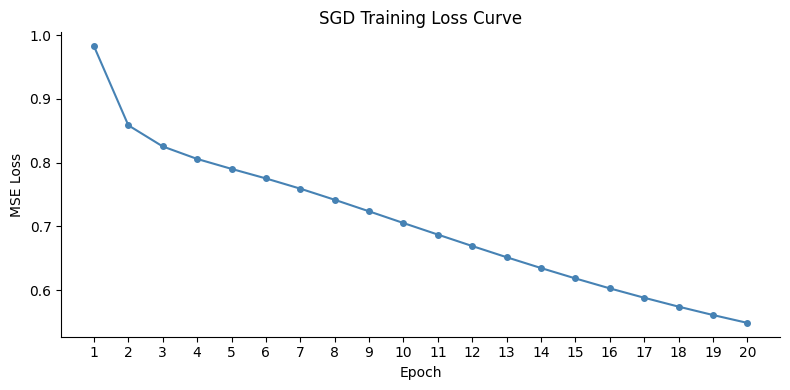

Initial loss : 0.9828
Final loss   : 0.5484
Improvement  : 44.2%


In [4]:
# plot training loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(mf_sgd.train_loss) + 1), mf_sgd.train_loss, color='steelblue', marker='o', markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('SGD Training Loss Curve')
ax.set_xticks(range(1, len(mf_sgd.train_loss) + 1))
plt.tight_layout()
plt.show()

print(f'Initial loss : {mf_sgd.train_loss[0]:.4f}')
print(f'Final loss   : {mf_sgd.train_loss[-1]:.4f}')
print(f'Improvement  : {(1 - mf_sgd.train_loss[-1] / mf_sgd.train_loss[0]) * 100:.1f}%')

In [5]:
# inspect learned biases
print('User bias stats:')
print(f'  Mean : {mf_sgd._b_u.mean():.4f}')
print(f'  Std  : {mf_sgd._b_u.std():.4f}')
print(f'  Min  : {mf_sgd._b_u.min():.4f}')
print(f'  Max  : {mf_sgd._b_u.max():.4f}')

print('\nItem bias stats:')
print(f'  Mean : {mf_sgd._b_i.mean():.4f}')
print(f'  Std  : {mf_sgd._b_i.std():.4f}')
print(f'  Min  : {mf_sgd._b_i.min():.4f}')
print(f'  Max  : {mf_sgd._b_i.max():.4f}')

# movies with the highest and lowest item bias
top_bias_idx = np.argsort(mf_sgd._b_i)[::-1][:5]
bot_bias_idx = np.argsort(mf_sgd._b_i)[:5]

def idx_to_title(indices):
    return [
        movies.loc[movies['movieId'] == movie_decoder[i], 'title_clean'].values[0]
        for i in indices if movie_decoder[i] in movies['movieId'].values
    ]

print('\nMovies with highest item bias (universally well-liked):')
for title in idx_to_title(top_bias_idx):
    print(f'  {title}')

print('\nMovies with lowest item bias (universally disliked):')
for title in idx_to_title(bot_bias_idx):
    print(f'  {title}')

User bias stats:
  Mean : -0.0499
  Std  : 0.3289
  Min  : -2.2841
  Max  : 1.5893

Item bias stats:
  Mean : -0.1645
  Std  : 0.5108
  Min  : -1.9579
  Max  : 1.0531

Movies with highest item bias (universally well-liked):
  Sanjuro
  Shawshank Redemption, The
  Close Shave, A
  Schindler's List
  Wrong Trousers, The

Movies with lowest item bias (universally disliked):
  Kazaam
  Iron Eagle IV
  Amityville 3-D
  3 Ninjas: High Noon On Mega Mountain
  Turbo: A Power Rangers Movie


## 3. Matrix Factorization with SVD

SVD computes a closed-form solution by decomposing the mean-centered
user-item matrix. No learning rate or epochs — one call solves it.
The tradeoff: faster but less flexible than SGD.

In [6]:
mf_svd = MatrixFactorizationSVD(k=50, random_state=42)
mf_svd.fit(matrix)
print('SVD fitted.')

SVD complete — k=50, matrix shape: (6040, 3706)
SVD fitted.


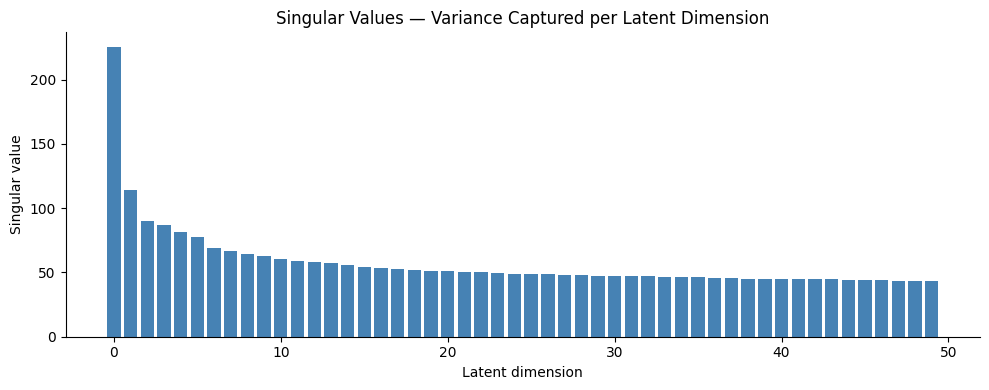

Top 10 dimensions capture 32.5% of total variance
Top 20 dimensions capture 51.7% of total variance


In [9]:
# singular values show how much variance each latent dimension captures
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(mf_svd._sigma)), sorted(mf_svd._sigma, reverse=True), color='steelblue')
ax.set_xlabel('Latent dimension')
ax.set_ylabel('Singular value')
ax.set_title('Singular Values — Variance Captured per Latent Dimension')
plt.tight_layout()
plt.show()

sigma_sorted = np.sort(mf_svd._sigma)[::-1]
cumvar = np.cumsum(sigma_sorted) / sigma_sorted.sum()
print(f'Top 10 dimensions capture {cumvar[9]:.1%} of total variance')
print(f'Top 20 dimensions capture {cumvar[19]:.1%} of total variance')

## 4. Latent Space Visualization

The learned item latent vectors live in k-dimensional space.
We use PCA to project them down to 2D for visualization.
Movies with similar latent representations should cluster together.

In [10]:
# use SVD item factors for visualization
# Vt shape: (k, n_movies) -> transpose to (n_movies, k)
item_factors = mf_svd._Vt.T

pca = PCA(n_components=2, random_state=42)
item_2d = pca.fit_transform(item_factors)

print(f'Item factors shape : {item_factors.shape}')
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}')

Item factors shape : (3706, 50)
PCA explained variance: 4.0%


In [11]:
# build a plot DataFrame — sample 500 movies for readability
rng = np.random.default_rng(42)
sample_indices = rng.choice(len(item_2d), size=min(500, len(item_2d)), replace=False)

plot_df = pd.DataFrame({
    'x': item_2d[sample_indices, 0],
    'y': item_2d[sample_indices, 1],
    'movie_idx': sample_indices
})
plot_df['movieId'] = plot_df['movie_idx'].map(movie_decoder)
plot_df = plot_df.merge(movies[['movieId', 'title_clean', 'genres']], on='movieId', how='left')
plot_df['primary_genre'] = plot_df['genres'].apply(lambda g: g[0] if isinstance(g, list) and g else 'Unknown')

fig = px.scatter(
    plot_df,
    x='x',
    y='y',
    color='primary_genre',
    hover_data=['title_clean'],
    title='Movie Latent Space (SVD factors projected to 2D via PCA)',
    labels={'x': 'PC1', 'y': 'PC2', 'primary_genre': 'Primary Genre'},
    opacity=0.7
)
fig.update_traces(marker=dict(size=5))
fig.show()

## 5. Qualitative Recommendation Inspection

In [12]:
def get_recommendations(model, user_idx, n=10, model_type='sgd'):
    rated_indices = set(matrix[user_idx].nonzero()[1])
    rated_mask = np.zeros(n_movies, dtype=bool)
    rated_mask[list(rated_indices)] = True

    recs = model.recommend(user_idx, n=n, rated_mask=rated_mask)
    rec_df = pd.DataFrame(recs, columns=['movie_idx', 'predicted_score'])
    rec_df['movieId'] = rec_df['movie_idx'].map(movie_decoder)
    rec_df = rec_df.merge(movies[['movieId', 'title_clean', 'genres']], on='movieId', how='left')
    rec_df['genres'] = rec_df['genres'].apply(lambda g: ', '.join(g) if isinstance(g, list) else g)
    return rec_df[['title_clean', 'genres', 'predicted_score']].round(3)


def get_user_history(user_idx, n=10):
    user_rated = train[train['user_idx'] == user_idx].sort_values('rating', ascending=False).head(n).copy()
    user_rated['movieId'] = user_rated['movie_idx'].map(movie_decoder)
    user_rated = user_rated.merge(movies[['movieId', 'title_clean', 'genres']], on='movieId', how='left')
    user_rated['genres'] = user_rated['genres'].apply(lambda g: ', '.join(g) if isinstance(g, list) else g)
    return user_rated[['title_clean', 'genres', 'rating']]

In [13]:
sample_user_idx = 42

print('=== User history (top rated) ===')
display(get_user_history(sample_user_idx))

print('\n=== SGD recommendations ===')
display(get_recommendations(mf_sgd, sample_user_idx))

print('\n=== SVD recommendations ===')
display(get_recommendations(mf_svd, sample_user_idx))

=== User history (top rated) ===


,title_clean,genres,rating



=== SGD recommendations ===


,title_clean,genres,predicted_score
0,"Shawshank Redemption, The",Drama,4.706
1,Schindler's List,"Drama, War",4.642
2,After Life,Drama,4.638
3,Paths of Glory,"Drama, War",4.620
4,American History X,Drama,4.618
5,"400 Blows, The (Les Quatre cents coups)",Drama,4.616
6,There's Something About Mary,Comedy,4.597
7,"World of Apu, The (Apur Sansar)",Drama,4.596
8,"Pawnbroker, The",Drama,4.590
9,"Sixth Sense, The",Thriller,4.584



=== SVD recommendations ===


,title_clean,genres,predicted_score
0,Toy Story,"Animation, Children's, Comedy",1.0
1,"Contender, The","Drama, Thriller",1.0
2,Two Family House,Drama,1.0
3,Tigerland,Drama,1.0
4,Requiem for a Dream,Drama,1.0
5,Meet the Parents,Comedy,1.0
6,Get Carter,Thriller,1.0
7,Get Carter,"Action, Drama, Thriller",1.0
8,Digimon: The Movie,"Adventure, Animation, Children's",1.0
9,Bootmen,"Comedy, Drama",1.0


## 6. Evaluation and Comparison

In [14]:
print('Evaluating SGD...')
rmse_sgd = evaluate_mf_sgd(mf_sgd, test)
print(f'SGD RMSE: {rmse_sgd:.4f}')

print('\nEvaluating SVD...')
rmse_svd = evaluate_mf_svd(mf_svd, test)
print(f'SVD RMSE: {rmse_svd:.4f}')

Evaluating SGD...
SGD RMSE: 0.9539

Evaluating SVD...
SVD RMSE: 2.1040


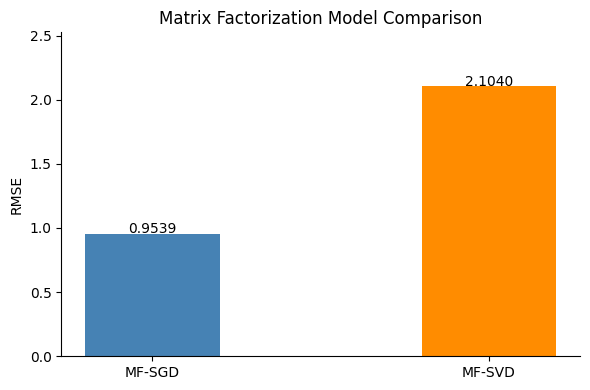

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
models = ['MF-SGD', 'MF-SVD']
rmses = [rmse_sgd, rmse_svd]
colors = ['steelblue', 'darkorange']

bars = ax.bar(models, rmses, color=colors, width=0.4)
for bar, rmse in zip(bars, rmses):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{rmse:.4f}', ha='center', fontsize=10
    )

ax.set_ylabel('RMSE')
ax.set_title('Matrix Factorization Model Comparison')
ax.set_ylim(0, max(rmses) * 1.2)
plt.tight_layout()
plt.show()

Training SGD with k=10...
Epoch   1/10  loss: 1.0294
Epoch   2/10  loss: 0.8824
Epoch   3/10  loss: 0.8460
Epoch   4/10  loss: 0.8285
Epoch   5/10  loss: 0.8179
Epoch   6/10  loss: 0.8103
Epoch   7/10  loss: 0.8042
Epoch   8/10  loss: 0.7987
Epoch   9/10  loss: 0.7933
Epoch  10/10  loss: 0.7875
  k= 10  RMSE=0.9634
Training SGD with k=20...
Epoch   1/10  loss: 1.0026
Epoch   2/10  loss: 0.8705
Epoch   3/10  loss: 0.8361
Epoch   4/10  loss: 0.8179
Epoch   5/10  loss: 0.8050
Epoch   6/10  loss: 0.7941
Epoch   7/10  loss: 0.7834
Epoch   8/10  loss: 0.7718
Epoch   9/10  loss: 0.7592
Epoch  10/10  loss: 0.7462
  k= 20  RMSE=0.9606
Training SGD with k=50...
Epoch   1/10  loss: 0.9828
Epoch   2/10  loss: 0.8586
Epoch   3/10  loss: 0.8254
Epoch   4/10  loss: 0.8058
Epoch   5/10  loss: 0.7902
Epoch   6/10  loss: 0.7752
Epoch   7/10  loss: 0.7591
Epoch   8/10  loss: 0.7417
Epoch   9/10  loss: 0.7236
Epoch  10/10  loss: 0.7052
  k= 50  RMSE=0.9532
Training SGD with k=100...
Epoch   1/10  loss: 0.

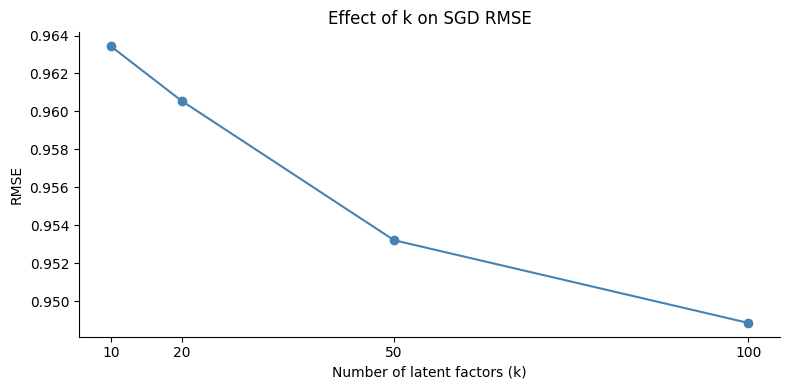

In [16]:
# experiment with different k values for SGD
k_values = [10, 20, 50, 100]
k_rmses = []

for k in k_values:
    print(f'Training SGD with k={k}...')
    model = MatrixFactorizationSGD(k=k, n_epochs=10, random_state=42)
    model.fit(matrix)
    rmse = evaluate_mf_sgd(model, test)
    k_rmses.append(rmse)
    print(f'  k={k:>3}  RMSE={rmse:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, k_rmses, color='steelblue', marker='o', markersize=6)
ax.set_xlabel('Number of latent factors (k)')
ax.set_ylabel('RMSE')
ax.set_title('Effect of k on SGD RMSE')
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

## Summary

- Both SGD and SVD factorization outperform naive CF from notebook 02
- SGD learns iteratively and benefits from bias terms — better for fine-tuning
- SVD is a one-shot analytical solution — faster but less flexible
- The latent space visualization shows that movies cluster by genre,
  confirming the model has learned meaningful representations without any content features
- The k sweep shows diminishing returns beyond a certain point,
  with risk of overfitting at very high k values
- The next notebook brings all models together for a final side-by-side evaluation